# Clustering time series
This notebook is going to be an organized way of cluster time series using an algorithm which can take multivariate data. The data will be structure in the following way: each phosphorylation site will be an entrance to the dataset, it will have 3 different variables which correspond to the different experiment conditions (EGF, INS, EGFnINS). 

 https://github.com/Kenan-Li/dtwsom 

In [1]:
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
# %matplotlib inline
import numpy as np
import os
import sys
import inspect

import dtwsom
import pickle
from sklearn.cluster import KMeans

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Steps:
- Load dataframe
- Reformating the dataframe to fit the multivariate project

In [2]:
df = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD_log2FC1_nRep2_allPhosphoFound_True.xlsx")
df

,protein_ID,prot_name,site,EGF_full,EGF_starve,EGF_1,EGF_2,EGF_5,EGF_10,EGF_90,...,sd_INS5,sd_INS10,sd_INS90,sd_full_EGFnINS,sd_starve_EGFnINS,sd_EGFnINS1,sd_EGFnINS2,sd_EGFnINS5,sd_EGFnINS10,sd_EGFnINS90
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,2.750617,0,-0.075632,0.051413,0.553841,1.071310,0.614675,...,0.132813,0.082451,0.158647,0.240242,0.073607,0.213038,0.017743,0.137722,0.158750,0.203929
1,A0JLT2,MED19,A0JLT2_226_242_1_1_S226~NRHsPDHPGMGSSQASSSSSLR,-0.818481,0,-0.973433,-1.193431,-1.378886,-0.892714,-0.948226,...,0.484981,0.470362,0.278314,0.424832,1.024998,1.014298,0.514937,0.009178,0.421768,1.305940
2,A1L390,PLEKHG3,A1L390_617_624_2_2_S617S618~RssVAQEDSK,0.918632,0,0.031426,0.263393,0.607975,1.104159,0.381136,...,0.175742,0.397785,0.322910,0.202589,0.425723,0.027715,0.168930,0.244848,0.278069,0.137290
3,A1L390,PLEKHG3,A1L390_741_744_1_1_S741~RREsLSYIPK,0.663055,0,0.522547,0.851359,0.985354,0.597517,0.182266,...,0.220746,0.237001,0.276208,0.224325,0.218766,0.090920,0.066996,0.075591,0.049475,0.072181
4,A1L390,PLEKHG3,A1L390_485_492_1_1_S488~RPSGRsPTSTEK,-0.350542,0,-0.094971,-0.175449,-1.217816,-1.450707,-0.342383,...,0.137094,0.468493,0.067227,0.100564,0.106731,0.012431,0.045052,0.173409,0.083995,0.272901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,Q9Y6M7,SLC4A7,Q9Y6M7_242_242_1_1_S242~KHsDPHLLER,-0.891342,0,-0.269462,-0.715415,-1.310903,-1.175157,-0.627477,...,0.144940,0.119752,0.245584,0.287443,0.118665,0.200844,0.153688,0.242521,0.201050,0.255502
1113,Q9Y6Q9,NCOA3,Q9Y6Q9_857_867_1_1_S857~AVsLDSPVSVGSSPPVK,0.382016,0,0.188759,0.378108,0.946975,1.038999,0.147769,...,0.171608,0.339215,0.244854,0.182449,0.214897,0.141315,0.072214,0.081283,0.124413,0.110100
1114,Q9Y6R4,MAP3K4,Q9Y6R4_1227_1228_1_1_S1228~GSsVPENDR,1.182921,0,0.122977,0.235073,0.639236,0.886597,0.927117,...,0.176892,0.101112,0.276998,0.173005,0.105378,0.198766,0.128949,0.120089,0.093858,0.126145
1115,Q9Y6X9,MORC2,Q9Y6X9_739_743_1_1_S743~SVAVsDEEEVEEEAERR,-0.411413,0,-0.013029,-0.037583,-0.683015,-1.073718,-0.181425,...,0.119793,0.184561,0.132265,0.028969,0.122729,0.181125,0.055988,0.194354,0.210178,0.119344


In [3]:
times = ['EGF_full', 'EGF_starve', 'EGF_1', 'EGF_2', 'EGF_5', 'EGF_10', 'EGF_90',
         'INS_full', 'INS_starve', 'INS_1', 'INS_2', 'INS_5', 'INS_10', 'INS_90',
         'EGFnINS_full', 'EGFnINS_starve', 'EGFnINS_1', 'EGFnINS_2', 'EGFnINS_5', 'EGFnINS_10', 'EGFnINS_90']

In [4]:
def reshape_df(df, time_series, dimensions, len_time_serie):
    '''Reshape dataframe so it is multivariate. Return the dataframe in numpy format so can be used, and list with the names of myseries'''
    
    sub_df = df[time_series].copy()
    mySeries = sub_df.to_numpy()
    namesofMySeries = df["site"]
    
    multivariate_shape = (len(df), dimensions, len_time_serie)
    multivariate_df = np.reshape(mySeries, multivariate_shape)
    
    return multivariate_df, namesofMySeries
    

In [5]:
multivariate_df, names_of_myseries = reshape_df(df = df, time_series = times, dimensions = 3, len_time_serie = 7)

In [6]:
som = dtwsom.MultiDtwSom(x=9, y=9, input_len=multivariate_df.shape[2], bands=multivariate_df.shape[1], w=[1/3, 1/3, 1/3], sigma=1, learning_rate=0.5, random_seed=10, gl_const="sakoe_chiba", scr= 2)
som.pca_weights_init(multivariate_df)
som.train_batch(multivariate_df, 1000, verbose=True)
weights = som.get_weights()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
 [    0 / 1000 ]   0% - ? it/sIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
 [ 1000 / 1000 ] 100% - 11.24 it/s - 0:00:00 left  - quantization error: 0.48077844200711234


In [ ]:
## Save the model so that you do not need to train it again
#with open('multivariate_model_full_data.pkl', 'wb') as f:
#    pickle.dump(som, f)

In [7]:
KMeans_X = np.stack((np.array(weights)[0]+np.array(weights)[1]+np.array(weights)[2]).reshape(81, 7))
KMeans_all = KMeans(n_clusters=8, random_state=0).fit(KMeans_X)
KMeans_all.labels_

array([1, 1, 7, 7, 3, 3, 3, 3, 3, 1, 1, 7, 7, 3, 3, 3, 3, 3, 1, 1, 7, 7,
       3, 3, 3, 3, 0, 1, 1, 7, 2, 3, 3, 3, 0, 0, 1, 1, 7, 2, 2, 3, 0, 0,
       0, 1, 1, 7, 2, 2, 2, 0, 0, 0, 1, 1, 5, 2, 2, 6, 0, 0, 4, 1, 1, 5,
       2, 2, 6, 6, 4, 4, 1, 1, 5, 2, 2, 6, 6, 4, 4], dtype=int32)

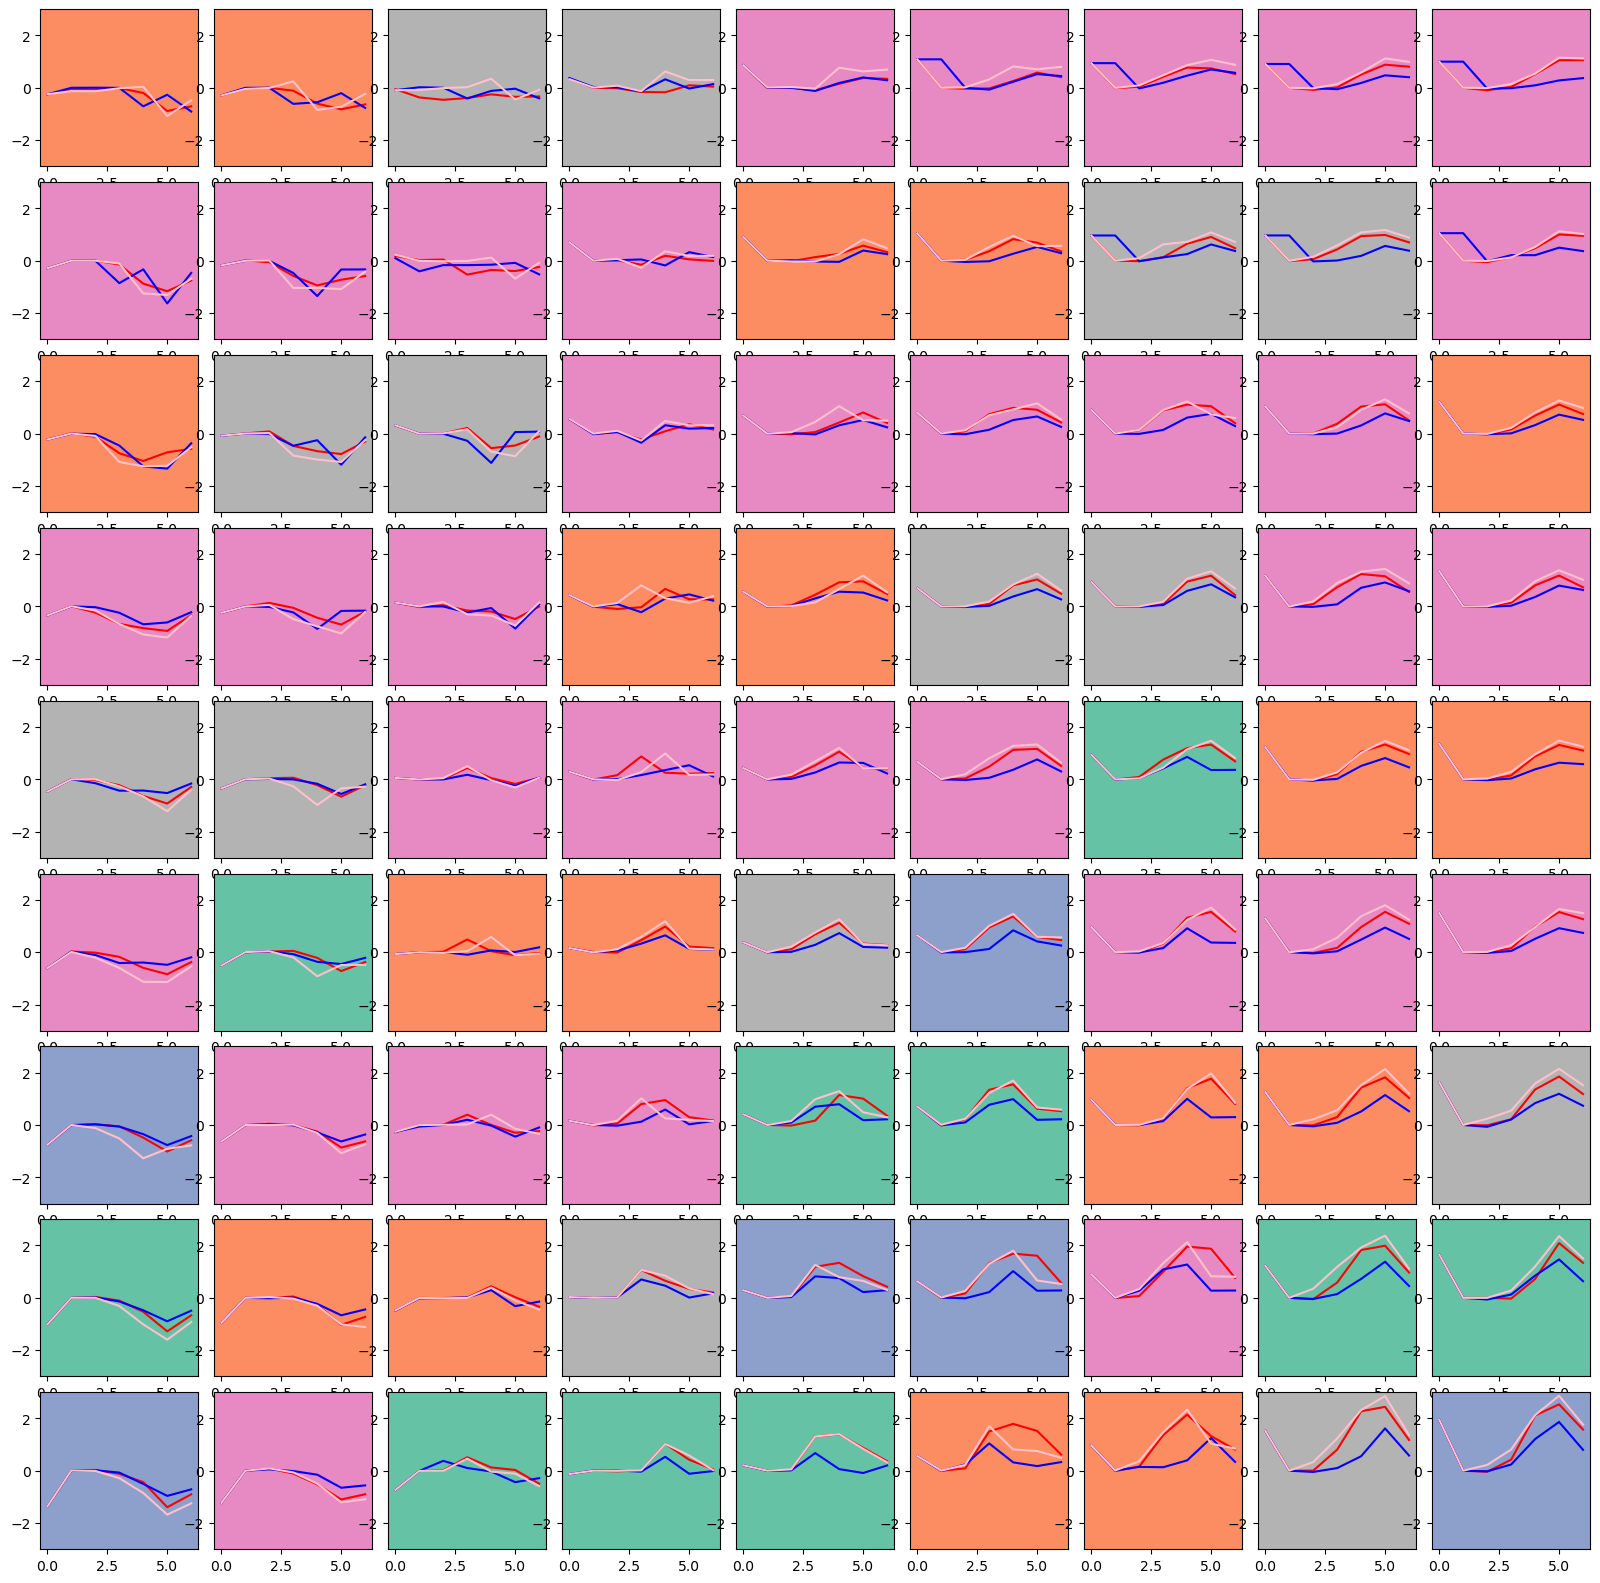

In [8]:
plt.figure(figsize=(20, 20))
norm = matplotlib.colors.Normalize(vmin=0, vmax=7, clip=True)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.Set2)
for i in range(9):
    maxylim= np.max(names_of_myseries)
    for j in range(9):
        ax = plt.subplot(9, 9, i*9 + 1+j)
        ax.get_xaxis().set_visible(True)
        ax.get_yaxis().set_visible(True)
        ax.set_ylim((-3,3))
        plt.plot(np.array(weights)[0, i, j, :], color= 'red')
        plt.plot(np.array(weights)[1, i, j, :], color= 'blue')
        plt.plot(np.array(weights)[2, i, j, :], color= 'pink')

        ax.set_facecolor(mapper.to_rgba(KMeans_all.labels_[i*5 +j]))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [11]:
all_winners_by_site_df = pd.DataFrame(index = names_of_myseries, columns = range(8), data = 0)
for s in all_winners_by_site_df.index:
    data = df[df.site==s]
    data_s = np.swapaxes(np.array([np.stack(multivariate_df[0]), np.stack(multivariate_df[1]), np.stack(multivariate_df[2])]), 0, 1)
    for i in data_s:
        x = som.winner(i)[0]
        y = som.winner(i)[1]
        all_winners_by_site_df.loc[s,KMeans_all.labels_[x*10 +y]] += 1
all_winners_by_site_df

,0,1,2,3,4,5,6,7
site,,,,,,,,
A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,0,0,0,3,0,0,0,0
A0JLT2_226_242_1_1_S226~NRHsPDHPGMGSSQASSSSSLR,0,0,0,3,0,0,0,0
A1L390_617_624_2_2_S617S618~RssVAQEDSK,0,0,0,3,0,0,0,0
A1L390_741_744_1_1_S741~RREsLSYIPK,0,0,0,3,0,0,0,0
A1L390_485_492_1_1_S488~RPSGRsPTSTEK,0,0,0,3,0,0,0,0
...,...,...,...,...,...,...,...,...
Q9Y6M7_242_242_1_1_S242~KHsDPHLLER,0,0,0,3,0,0,0,0
Q9Y6Q9_857_867_1_1_S857~AVsLDSPVSVGSSPPVK,0,0,0,3,0,0,0,0
Q9Y6R4_1227_1228_1_1_S1228~GSsVPENDR,0,0,0,3,0,0,0,0


In [13]:
winners_in_map = som.labels_map(multivariate_df, names_of_myseries)
winners_in_map #??????

defaultdict(list,
            {(6,
              8): Counter({'A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR': 1,
                      'O43149_981_984_1_1_S984~STDsGAK': 1,
                      'O60343_588_591_1_1_S588~LGsVDSFER': 1,
                      'O60825_482_486_1_1_S483~NYsVGSR': 1,
                      'P00533_693_695_1_1_T693~ELVEPLtPSGEAPNQALLR': 1,
                      'P04049_43_52_1_1_S43~RAsDDGKLTDPSK': 1,
                      'P08670_37_42_1_1_S39~TYsLGSALR': 1,
                      'P19634_703_708_1_1_S703~IGsDPLAYEPK': 1,
                      'P23443_427_427_1_1_S427~EKFsFEPK': 1,
                      'P23588_418_434_2_2_T420S424~SRtGSEsSQTGTSTTSSR': 1,
                      'P29375_223_231_1_1_S225~TQsESGDVSR': 1,
                      'P35568_329_351_1_1_S330~ASsDGEGTMSRPASVDGSPVSPSTNR': 1,
                      'P49792_2480_2504_1_1_T2504~TDVIQGDDVADATSEVEVSSTSETtPK': 1,
                      'Q00653_161_167_1_1_S161~sRPQGLTEAEQR': 1,
                      'Q096

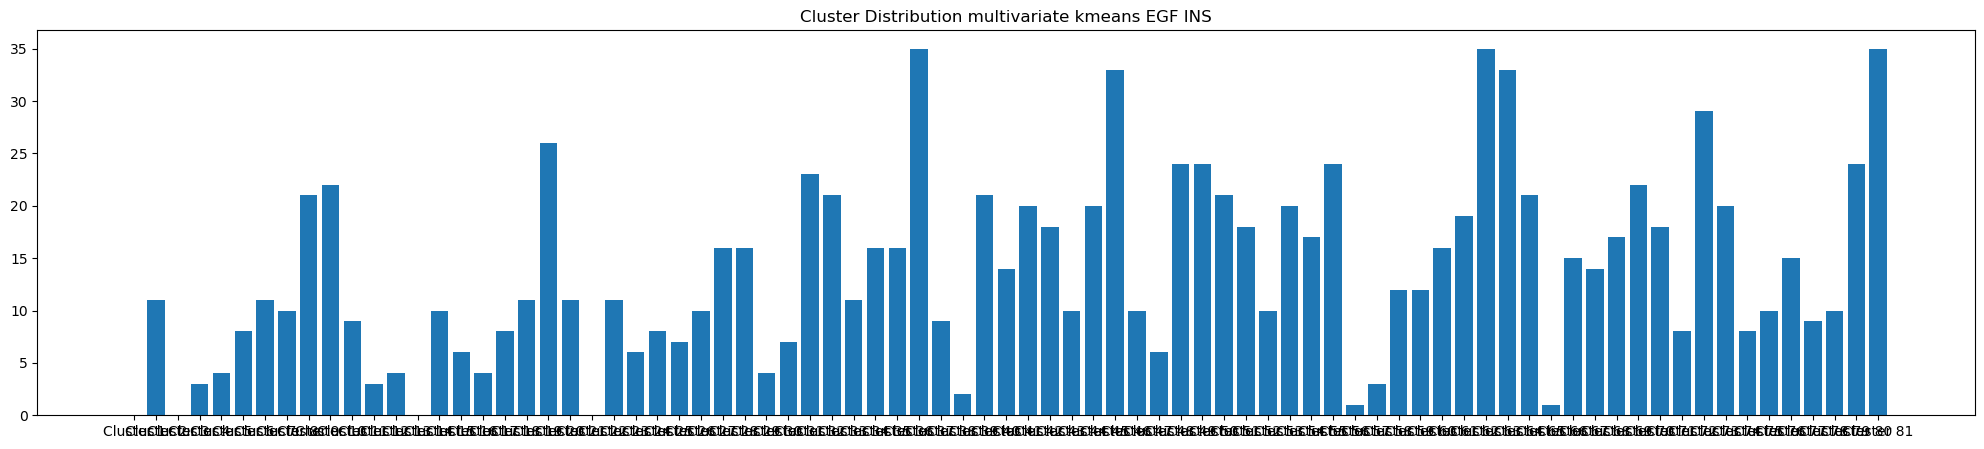

In [14]:
win_map = som.win_map(multivariate_df)
cluster_c = []
cluster_n = []
for x in range(9):
    for y in range(9):
        cluster = (x,y)
        if cluster in win_map.keys():
            cluster_c.append(len(win_map[cluster]))
        else:
            cluster_c.append(0)
        cluster_number = x*9+y+1
        cluster_n.append(f"Cluster {cluster_number}")

plt.figure(figsize=(25,5))
plt.title("Cluster Distribution multivariate kmeans EGF INS")
plt.bar(cluster_n,cluster_c)
# plt.savefig(f"Multivariate_EGF_INS/Kmean_weights_distribution.pdf", format = "pdf")
plt.show()

In [16]:
#this chunk of code still needs to be fixed, doesnt show properly the codes
cluster_map = []
for idx in range(len(multivariate_df)):
    winner_node = som.winner(multivariate_df[idx])
    cluster_map.append((names_of_myseries[idx],f"Cluster {winner_node[0]*9+winner_node[1]+1}"))
                        #multivariate_df[idx]
save_cluster = pd.DataFrame(cluster_map,columns=["Series","Cluster"]).sort_values(by="Cluster")
# save_cluster.to_excel(f"Multivariate_EGF_INS/Clustering.xlsx")
save_cluster

,Series,Cluster
579,Q6NZY4_419_427_1_1_S427~SSSHSSPGsPKK,Cluster 10
811,Q96HP0_30_36_1_1_S32~SGsPHSSR,Cluster 10
1102,Q9Y5S2_1677_1693_1_1_S1690~HSTPSNSSNPSGPPsPNSPHR,Cluster 10
1078,Q9Y3C5_7_21_1_1_S14~SPTSDDIsLLHESQSDR,Cluster 10
776,Q92597_344_352_1_1_S352~SHTSEGTRsR,Cluster 10
...,...,...
968,Q9P0L0_209_219_1_1_S214~VAHSDKPGsTSTASFR,Cluster 9
380,Q12774_445_452_1_1_S450~AEELSPAALsPSLEPIR,Cluster 9
173,P15407_251_267_1_1_T267~KSSSSSGDPSSDPLGSPtLLAL,Cluster 9
1104,Q9Y613_523_534_1_1_S523~EPLIPAsPKAEPIWELPTR,Cluster 9


In [ ]:
clustered_df = df.copy()
clustered_df['Clusters'] = False
for row in clustered_df.itertuples():
    index = row[0]
    site = row[3]
    # print(row[48])
    clustered_df.at[index,"Clusters"] = save_cluster.loc[index]['Cluster']
clustered_df

In [ ]:
# clustered_df.to_excel(f"clustered_df_FC1_25.xlsx", index=False)